In [59]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [60]:
data_path = Path("../data/raw/S1_A1_E2.mat")

data_e2 = loadmat(data_path)

data_e2.keys()

dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])

In [61]:
emg_e2 = data_e2["emg"]

labels_e2 = data_e2["restimulus"].flatten()

repetitions_e2 = data_e2["rerepetition"].flatten()

print("EMG shape:", emg_e2.shape)
print("Labels shape:", labels_e2.shape)
print("Repetitions shape:", repetitions_e2.shape)

print("Unique labels:", np.unique(labels_e2))
print("Unique repetitions:", np.unique(repetitions_e2))

EMG shape: (142976, 10)
Labels shape: (142976,)
Repetitions shape: (142976,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Unique repetitions: [ 0  1  2  3  4  5  6  7  8  9 10]


In [62]:
#commands
command_map = {
    0: "Rest",
    6: "Fist",
    7: "Point",
    8: "Open/Extended Hand",
    13: "Wrist Flexion",
    14: "Wrist Extension"
}

In [63]:
active_commands = [6, 7, 8, 13, 14]

In [64]:
def create_windows(signal, window_size=20, step_size=10):
    windows = []

    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end])

    return np.array(windows)

In [65]:
def extract_features(X):
    mav = np.mean(np.abs(X), axis=1)

    rms = np.sqrt(
        np.mean(X ** 2, axis=1)
    )

    wl = np.sum(
        np.abs(np.diff(X, axis=1)),
        axis=1
    )

    return np.concatenate(
        [mav, rms, wl],
        axis=1
    )

In [66]:
#build dataset
X_active = []
y_active = []
rep_active = []

for movement in active_commands:
    for rep in range(1, 11):

        mask = (
            (labels_e2 == movement) &
            (repetitions_e2 == rep)
        )

        signal = emg_e2[mask]

        windows = create_windows(
            signal,
            window_size=20,
            step_size=10
        )

        for window in windows:
            X_active.append(window)
            y_active.append(movement)
            rep_active.append(rep)

X_active = np.array(X_active)
y_active = np.array(y_active)
rep_active = np.array(rep_active)

print("X shape:", X_active.shape)
print("y shape:", y_active.shape)
print("Repetition shape:", rep_active.shape)
print("Labels:", np.unique(y_active))

X shape: (1413, 20, 10)
y shape: (1413,)
Repetition shape: (1413,)
Labels: [ 6  7  8 13 14]


In [67]:
for movement in active_commands:
    print(
        command_map[movement],
        ":",
        np.sum(y_active == movement)
    )

Fist : 353
Point : 294
Open/Extended Hand : 273
Wrist Flexion : 298
Wrist Extension : 195


In [68]:
#find rest periods

In [69]:
rest_mask = labels_e2 == 0

rest_segments = []

start = None

for i, is_rest in enumerate(rest_mask):
    if is_rest and start is None:
        start = i

    elif not is_rest and start is not None:
        rest_segments.append(emg_e2[start:i])
        start = None

# Catch a rest period that reaches the end of the recording
if start is not None:
    rest_segments.append(emg_e2[start:])

print("Number of separate rest periods:", len(rest_segments))

Number of separate rest periods: 171


In [70]:
print("First 10 rest segment lengths:")

for segment in rest_segments[:10]:
    print(len(segment))

First 10 rest segment lengths:
454
454
459
605
533
573
395
406
626
413


In [71]:
for movement in active_commands:
    print(
        f"{command_map[movement]}:",
        np.sum(y_active == movement)
    )

Fist: 353
Point: 294
Open/Extended Hand: 273
Wrist Flexion: 298
Wrist Extension: 195


In [72]:
target_rest_windows = round(len(X_active) / len(active_commands))

print("Target rest windows:", target_rest_windows)

Target rest windows: 283


In [73]:
#recreate rest segments
rest_ranges = []

start = None

for i, is_rest in enumerate(labels_e2 == 0):

    if is_rest and start is None:
        start = i

    elif not is_rest and start is not None:
        rest_ranges.append((start, i))
        start = None

if start is not None:
    rest_ranges.append((start, len(labels_e2)))

print(len(rest_ranges))

171


In [74]:
#assign each rest to a rep
rest_segment_reps = []

for start, end in rest_ranges:

    # Look immediately after the rest period
    if end < len(repetitions_e2):
        next_rep = repetitions_e2[end]
    else:
        next_rep = 0

    # If no active repetition follows, look backward
    if next_rep == 0:
        previous_idx = start - 1

        while (
            previous_idx >= 0
            and repetitions_e2[previous_idx] == 0
        ):
            previous_idx -= 1

        if previous_idx >= 0:
            next_rep = repetitions_e2[previous_idx]

    rest_segment_reps.append(next_rep)

rest_segment_reps = np.array(rest_segment_reps)

print(
    "Rest repetition groups:",
    np.unique(rest_segment_reps)
)

Rest repetition groups: [ 1  2  3  4  5  6  7  8  9 10]


In [75]:
#window rest periods
X_rest_all = []
rep_rest_all = []

for (start, end), rep in zip(
    rest_ranges,
    rest_segment_reps
):

    signal = emg_e2[start:end]

    windows = create_windows(
        signal,
        window_size=20,
        step_size=10
    )

    for window in windows:
        X_rest_all.append(window)
        rep_rest_all.append(rep)

X_rest_all = np.array(X_rest_all)
rep_rest_all = np.array(rep_rest_all)

print("All rest windows:", X_rest_all.shape)
print(
    "Rest repetition groups:",
    np.unique(rep_rest_all)
)

All rest windows: (8731, 20, 10)
Rest repetition groups: [ 1  2  3  4  5  6  7  8  9 10]


In [76]:
#sample rest across reps
rng = np.random.default_rng(42)

rest_windows = []
rest_rep_ids = []

windows_per_rep = 28

In [77]:
for rep in range(1, 11):

    rep_indices = np.where(
        rep_rest_all == rep
    )[0]

    selected = rng.choice(
        rep_indices,
        size=windows_per_rep,
        replace=False
    )

    rest_windows.append(
        X_rest_all[selected]
    )

    rest_rep_ids.extend(
        [rep] * windows_per_rep
    )

X_rest = np.concatenate(rest_windows)

y_rest = np.zeros(len(X_rest), dtype=int)

rep_rest = np.array(rest_rep_ids)

print("Rest X:", X_rest.shape)
print("Rest y:", y_rest.shape)
print("Rest repetitions:", rep_rest.shape)

Rest X: (280, 20, 10)
Rest y: (280,)
Rest repetitions: (280,)


In [78]:
#combine active and rest windows
X_commands = np.concatenate(
    [X_active, X_rest],
    axis=0
)

y_commands = np.concatenate(
    [y_active, y_rest],
    axis=0
)

rep_commands = np.concatenate(
    [rep_active, rep_rest],
    axis=0
)

print("X shape:", X_commands.shape)
print("y shape:", y_commands.shape)
print("Repetition shape:", rep_commands.shape)

print("Labels:", np.unique(y_commands))

X shape: (1693, 20, 10)
y shape: (1693,)
Repetition shape: (1693,)
Labels: [ 0  6  7  8 13 14]


In [79]:
for label in np.unique(y_commands):
    print(
        f"{command_map[label]}:",
        np.sum(y_commands == label)
    )

Rest: 280
Fist: 353
Point: 294
Open/Extended Hand: 273
Wrist Flexion: 298
Wrist Extension: 195


In [80]:
X_command_features = extract_features(X_commands)

print(X_command_features.shape)

(1693, 30)


In [81]:
#create and train model

In [82]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

In [83]:
logo = LeaveOneGroupOut()

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

scores = []

for train_idx, test_idx in logo.split(
    X_command_features,
    y_commands,
    groups=rep_commands
):

    model.fit(
        X_command_features[train_idx],
        y_commands[train_idx]
    )

    predictions = model.predict(
        X_command_features[test_idx]
    )

    score = accuracy_score(
        y_commands[test_idx],
        predictions
    )

    scores.append(score)

print(
    f"Mean accuracy: {np.mean(scores) * 100:.2f}% "
    f"+/- {np.std(scores) * 100:.2f}%"
)

Mean accuracy: 85.67% +/- 6.75%


In [84]:
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

cv_predictions = np.zeros_like(y_commands)

for train_idx, test_idx in logo.split(
    X_command_features,
    y_commands,
    groups=rep_commands
):
    fold_model = clone(model)

    fold_model.fit(
        X_command_features[train_idx],
        y_commands[train_idx]
    )

    cv_predictions[test_idx] = fold_model.predict(
        X_command_features[test_idx]
    )

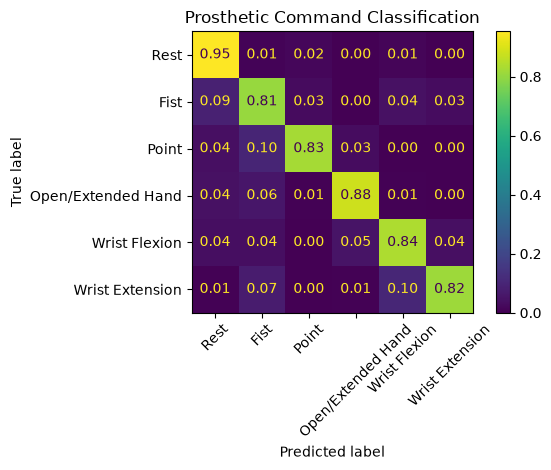

In [85]:
ConfusionMatrixDisplay.from_predictions(
    y_commands,
    cv_predictions,
    labels=list(command_map.keys()),
    display_labels=[
        command_map[label]
        for label in command_map
    ],
    normalize="true",
    values_format=".2f"
)

plt.title("Prosthetic Command Classification")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
print(
    classification_report(
        y_commands,
        cv_predictions,
        labels=list(command_map.keys()),
        target_names=[
            command_map[label]
            for label in command_map
        ]
    )
)

                    precision    recall  f1-score   support

              Rest       0.80      0.95      0.87       280
              Fist       0.80      0.81      0.80       353
             Point       0.93      0.83      0.88       294
Open/Extended Hand       0.90      0.88      0.89       273
     Wrist Flexion       0.86      0.84      0.85       298
   Wrist Extension       0.87      0.82      0.84       195

          accuracy                           0.85      1693
         macro avg       0.86      0.85      0.85      1693
      weighted avg       0.86      0.85      0.85      1693



In [87]:
from sklearn.metrics import confusion_matrix

labels_order = [0, 6, 7, 8, 13, 14]

cm = confusion_matrix(
    y_commands,
    cv_predictions,
    labels=labels_order
)

confusions = []

for i, actual in enumerate(labels_order):
    for j, predicted in enumerate(labels_order):

        if actual != predicted and cm[i, j] > 0:
            confusions.append(
                (
                    cm[i, j],
                    command_map[actual],
                    command_map[predicted]
                )
            )

confusions.sort(reverse=True)

for count, actual, predicted in confusions[:10]:
    print(
        f"{actual} → {predicted}: {count} windows"
    )

Fist → Rest: 31 windows
Point → Fist: 29 windows
Wrist Extension → Wrist Flexion: 20 windows
Open/Extended Hand → Fist: 16 windows
Wrist Flexion → Open/Extended Hand: 15 windows
Fist → Wrist Flexion: 15 windows
Wrist Extension → Fist: 14 windows
Wrist Flexion → Wrist Extension: 12 windows
Point → Rest: 12 windows
Open/Extended Hand → Rest: 12 windows


In [88]:
#model comparison

In [89]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "LDA": make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis()
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    ),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC()
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [90]:
model_results = {}

for name, model in models.items():

    scores = []

    for train_idx, test_idx in logo.split(
        X_command_features,
        y_commands,
        groups=rep_commands
    ):

        model.fit(
            X_command_features[train_idx],
            y_commands[train_idx]
        )

        predictions = model.predict(
            X_command_features[test_idx]
        )

        scores.append(
            accuracy_score(
                y_commands[test_idx],
                predictions
            )
        )

    model_results[name] = scores

    print(
        f"{name}: "
        f"{np.mean(scores) * 100:.2f}% "
        f"+/- {np.std(scores) * 100:.2f}%"
    )

LDA: 77.61% +/- 6.78%
Logistic Regression: 85.67% +/- 6.75%
SVM: 82.82% +/- 6.88%
Random Forest: 87.86% +/- 5.49%


In [91]:
#random forest predictions

In [92]:
from sklearn.base import clone

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_cv_predictions = np.zeros_like(y_commands)

for train_idx, test_idx in logo.split(
    X_command_features,
    y_commands,
    groups=rep_commands
):
    fold_model = clone(rf_model)

    fold_model.fit(
        X_command_features[train_idx],
        y_commands[train_idx]
    )

    rf_cv_predictions[test_idx] = fold_model.predict(
        X_command_features[test_idx]
    )

In [93]:
print(
    classification_report(
        y_commands,
        rf_cv_predictions,
        labels=[0, 6, 7, 8, 13, 14],
        target_names=[
            "Rest",
            "Fist",
            "Point",
            "Open/Extended Hand",
            "Wrist Flexion",
            "Wrist Extension"
        ]
    )
)

                    precision    recall  f1-score   support

              Rest       0.87      0.95      0.91       280
              Fist       0.84      0.82      0.83       353
             Point       0.93      0.85      0.88       294
Open/Extended Hand       0.90      0.92      0.91       273
     Wrist Flexion       0.86      0.87      0.86       298
   Wrist Extension       0.88      0.84      0.86       195

          accuracy                           0.87      1693
         macro avg       0.88      0.88      0.88      1693
      weighted avg       0.87      0.87      0.87      1693



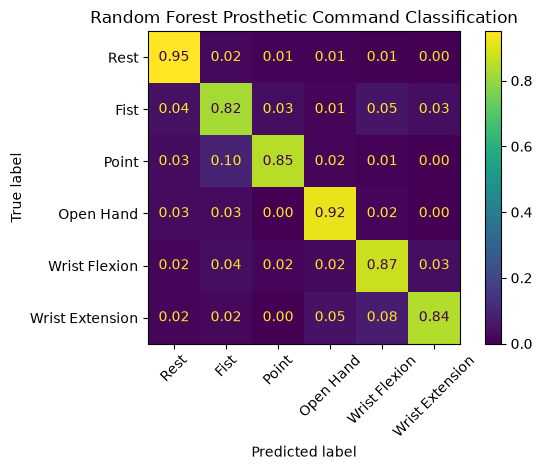

In [94]:
ConfusionMatrixDisplay.from_predictions(
    y_commands,
    rf_cv_predictions,
    labels=[0, 6, 7, 8, 13, 14],
    display_labels=[
        "Rest",
        "Fist",
        "Point",
        "Open Hand",
        "Wrist Flexion",
        "Wrist Extension"
    ],
    normalize="true",
    values_format=".2f"
)

plt.title("Random Forest Prosthetic Command Classification")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
cm_rf = confusion_matrix(
    y_commands,
    rf_cv_predictions,
    labels=[0, 6, 7, 8, 13, 14]
)

labels_order = [0, 6, 7, 8, 13, 14]

rf_confusions = []

for i, actual in enumerate(labels_order):
    for j, predicted in enumerate(labels_order):

        if actual != predicted and cm_rf[i, j] > 0:
            rf_confusions.append(
                (
                    cm_rf[i, j],
                    command_map[actual],
                    command_map[predicted]
                )
            )

rf_confusions.sort(reverse=True)

for count, actual, predicted in rf_confusions[:10]:
    print(f"{actual} → {predicted}: {count} windows")

Point → Fist: 28 windows
Fist → Wrist Flexion: 19 windows
Wrist Extension → Wrist Flexion: 15 windows
Fist → Rest: 15 windows
Fist → Wrist Extension: 12 windows
Fist → Point: 12 windows
Wrist Flexion → Fist: 11 windows
Wrist Flexion → Wrist Extension: 10 windows
Wrist Extension → Open/Extended Hand: 9 windows
Point → Rest: 9 windows


In [96]:
#deployment model v1

In [97]:
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

final_model.fit(
    X_command_features,
    y_commands
)

print("Final model trained!")

Final model trained!


In [98]:
import joblib

In [99]:
joblib.dump(
    final_model,
    "../models/prosthetic_command_rf.joblib"
)

['../models/prosthetic_command_rf.joblib']

In [100]:
loaded_model = joblib.load(
    "../models/prosthetic_command_rf.joblib"
)

print(loaded_model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [101]:
example = X_command_features[0].reshape(1, -1)

prediction = loaded_model.predict(example)[0]

print("Predicted label:", prediction)
print("Predicted command:", command_map[prediction])
print("Actual command:", command_map[y_commands[0]])

Predicted label: 6
Predicted command: Fist
Actual command: Fist


In [102]:
#save controller config
controller_config = {
    "sampling_rate_hz": 100,
    "window_size_samples": 20,
    "window_duration_ms": 200,
    "step_size_samples": 10,
    "step_duration_ms": 100,
    "features": [
        "MAV",
        "RMS",
        "Waveform Length"
    ],
    "commands": command_map
}

controller_config

{'sampling_rate_hz': 100,
 'window_size_samples': 20,
 'window_duration_ms': 200,
 'step_size_samples': 10,
 'step_duration_ms': 100,
 'features': ['MAV', 'RMS', 'Waveform Length'],
 'commands': {0: 'Rest',
  6: 'Fist',
  7: 'Point',
  8: 'Open/Extended Hand',
  13: 'Wrist Flexion',
  14: 'Wrist Extension'}}

In [103]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

final_model.fit(
    X_command_features,
    y_commands
)

print("Final model trained!")

Final model trained!


In [104]:
import joblib

In [105]:
joblib.dump(
    final_model,
    "../models/prosthetic_command_rf.joblib"
)

['../models/prosthetic_command_rf.joblib']

In [106]:
loaded_model = joblib.load(
    "../models/prosthetic_command_rf.joblib"
)

print(loaded_model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [107]:
example = X_command_features[0].reshape(1, -1)

prediction = loaded_model.predict(example)[0]

print("Predicted:", command_map[prediction])
print("Actual:", command_map[y_commands[0]])

Predicted: Fist
Actual: Fist


In [108]:
controller_config = {
    "sampling_rate_hz": 100,
    "window_size_samples": 20,
    "window_duration_ms": 200,
    "step_size_samples": 10,
    "step_duration_ms": 100,
    "features": [
        "MAV",
        "RMS",
        "Waveform Length"
    ],
    "commands": command_map
}

In [109]:
joblib.dump(
    controller_config,
    "../models/controller_config.joblib"
)

['../models/controller_config.joblib']

In [110]:
print("Model classes:", loaded_model.classes_)
print("Commands:", command_map)

Model classes: [ 0  6  7  8 13 14]
Commands: {0: 'Rest', 6: 'Fist', 7: 'Point', 8: 'Open/Extended Hand', 13: 'Wrist Flexion', 14: 'Wrist Extension'}


In [111]:
from collections import deque
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

test_rep = 1

train_mask = rep_commands != test_rep

temporal_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

temporal_model.fit(
    X_command_features[train_mask],
    y_commands[train_mask]
)

print("Model trained without repetition 1")

Model trained without repetition 1


In [112]:
demo_commands = [6, 7, 8, 13, 14]

sequence_emg = []
sequence_labels = []

for command in demo_commands:

    indices = np.where(
        (labels_e2 == command)
        & (repetitions_e2 == test_rep)
    )[0]

    start = max(indices[0] - 100, 0)
    end = min(indices[-1] + 100, len(emg_e2))

    sequence_emg.append(
        emg_e2[start:end]
    )

    sequence_labels.append(
        labels_e2[start:end]
    )

sequence_emg = np.concatenate(sequence_emg)
sequence_labels = np.concatenate(sequence_labels)

In [114]:
window_size = 20
step_size = 10
history_length = 5

raw_predictions = []
smoothed_predictions = []
true_predictions = []

probability_history = deque(
    maxlen=history_length
)

for start in range(
    0,
    len(sequence_emg) - window_size + 1,
    step_size
):

    window = sequence_emg[
        start:start + window_size
    ]

    features = extract_features(
        window[np.newaxis, ...]
    )

    probabilities = temporal_model.predict_proba(
        features
    )[0]

    raw_prediction = temporal_model.classes_[
        np.argmax(probabilities)
    ]

    probability_history.append(
        probabilities
    )

    history = np.array(
        probability_history
    )

    weights = np.arange(
        1,
        len(history) + 1,
        dtype=float
    )

    weights /= weights.sum()

    smoothed_probabilities = np.average(
        history,
        axis=0,
        weights=weights
    )

    smoothed_prediction = temporal_model.classes_[
        np.argmax(smoothed_probabilities)
    ]

    center = start + window_size // 2

    true_label = sequence_labels[
        center
    ]

    raw_predictions.append(
        raw_prediction
    )

    smoothed_predictions.append(
        smoothed_prediction
    )

    true_predictions.append(
        true_label
    )

raw_predictions = np.array(raw_predictions)
smoothed_predictions = np.array(smoothed_predictions)
true_predictions = np.array(true_predictions)

In [115]:
raw_accuracy = accuracy_score(
    true_predictions,
    raw_predictions
)

smoothed_accuracy = accuracy_score(
    true_predictions,
    smoothed_predictions
)


def count_switches(predictions):
    return np.sum(
        predictions[1:]
        != predictions[:-1]
    )


print(
    f"Raw accuracy: "
    f"{raw_accuracy * 100:.2f}%"
)

print(
    f"Smoothed accuracy: "
    f"{smoothed_accuracy * 100:.2f}%"
)

print(
    "Raw command switches:",
    count_switches(raw_predictions)
)

print(
    "Smoothed command switches:",
    count_switches(smoothed_predictions)
)

Raw accuracy: 77.82%
Smoothed accuracy: 82.55%
Raw command switches: 43
Smoothed command switches: 30


In [116]:
all_results = []

for test_rep in range(1, 11):

    # Train without the test repetition
    train_mask = rep_commands != test_rep

    temporal_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    temporal_model.fit(
        X_command_features[train_mask],
        y_commands[train_mask]
    )

    # Build chronological test sequence
    sequence_emg = []
    sequence_labels = []

    for command in demo_commands:

        indices = np.where(
            (labels_e2 == command)
            & (repetitions_e2 == test_rep)
        )[0]

        if len(indices) == 0:
            continue

        start = max(
            indices[0] - 100,
            0
        )

        end = min(
            indices[-1] + 100,
            len(emg_e2)
        )

        sequence_emg.append(
            emg_e2[start:end]
        )

        sequence_labels.append(
            labels_e2[start:end]
        )

    sequence_emg = np.concatenate(
        sequence_emg
    )

    sequence_labels = np.concatenate(
        sequence_labels
    )

    raw_predictions = []
    smooth_predictions = []
    true_predictions = []

    probability_history = deque(
        maxlen=5
    )

    # Run controller
    for start in range(
        0,
        len(sequence_emg) - window_size + 1,
        step_size
    ):

        window = sequence_emg[
            start:start + window_size
        ]

        features = extract_features(
            window[np.newaxis, ...]
        )

        probabilities = temporal_model.predict_proba(
            features
        )[0]

        raw_prediction = temporal_model.classes_[
            np.argmax(probabilities)
        ]

        probability_history.append(
            probabilities
        )

        history = np.array(
            probability_history
        )

        weights = np.arange(
            1,
            len(history) + 1,
            dtype=float
        )

        weights /= weights.sum()

        smoothed_probabilities = np.average(
            history,
            axis=0,
            weights=weights
        )

        smooth_prediction = temporal_model.classes_[
            np.argmax(smoothed_probabilities)
        ]

        center = (
            start
            + window_size // 2
        )

        true_label = sequence_labels[
            center
        ]

        raw_predictions.append(
            raw_prediction
        )

        smooth_predictions.append(
            smooth_prediction
        )

        true_predictions.append(
            true_label
        )

    raw_predictions = np.array(
        raw_predictions
    )

    smooth_predictions = np.array(
        smooth_predictions
    )

    true_predictions = np.array(
        true_predictions
    )

    raw_accuracy = accuracy_score(
        true_predictions,
        raw_predictions
    )

    smooth_accuracy = accuracy_score(
        true_predictions,
        smooth_predictions
    )

    raw_switches = count_switches(
        raw_predictions
    )

    smooth_switches = count_switches(
        smooth_predictions
    )

    all_results.append({
        "repetition": test_rep,
        "raw_accuracy": raw_accuracy,
        "smooth_accuracy": smooth_accuracy,
        "raw_switches": raw_switches,
        "smooth_switches": smooth_switches,
    })

In [117]:
results_df = pd.DataFrame(
    all_results
)

results_df

,repetition,raw_accuracy,smooth_accuracy,raw_switches,smooth_switches
0,1,0.778182,0.825455,43,30
1,2,0.825726,0.838174,33,18
2,3,0.857778,0.853333,25,16
3,4,0.757322,0.774059,35,17
4,5,0.826923,0.811538,26,17
5,6,0.869388,0.865306,37,19
6,7,0.796813,0.824701,33,21
7,8,0.863636,0.876033,28,17
8,9,0.825758,0.829545,37,22
9,10,0.873874,0.891892,26,16


In [118]:
print(
    f"Raw accuracy: "
    f"{results_df['raw_accuracy'].mean() * 100:.2f}% "
    f"+/- "
    f"{results_df['raw_accuracy'].std() * 100:.2f}%"
)

print(
    f"Smoothed accuracy: "
    f"{results_df['smooth_accuracy'].mean() * 100:.2f}% "
    f"+/- "
    f"{results_df['smooth_accuracy'].std() * 100:.2f}%"
)

print(
    f"Average raw switches: "
    f"{results_df['raw_switches'].mean():.1f}"
)

print(
    f"Average smoothed switches: "
    f"{results_df['smooth_switches'].mean():.1f}"
)

Raw accuracy: 82.75% +/- 4.00%
Smoothed accuracy: 83.90% +/- 3.42%
Average raw switches: 32.3
Average smoothed switches: 19.3


In [119]:
history_length = 5

In [120]:
history_lengths = [1, 3, 5, 7, 10]

In [121]:
history_lengths = [1, 3, 5, 7, 10]

memory_results = []

for test_rep in range(1, 11):

    # Train only on the other repetitions
    train_mask = rep_commands != test_rep

    temporal_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    temporal_model.fit(
        X_command_features[train_mask],
        y_commands[train_mask]
    )

    # Build chronological sequence
    sequence_emg = []
    sequence_labels = []

    for command in demo_commands:

        indices = np.where(
            (labels_e2 == command)
            & (repetitions_e2 == test_rep)
        )[0]

        if len(indices) == 0:
            continue

        start = max(indices[0] - 100, 0)
        end = min(indices[-1] + 100, len(emg_e2))

        sequence_emg.append(
            emg_e2[start:end]
        )

        sequence_labels.append(
            labels_e2[start:end]
        )

    sequence_emg = np.concatenate(sequence_emg)
    sequence_labels = np.concatenate(sequence_labels)

    # Get probability predictions for every window
    probability_sequence = []
    true_sequence = []

    for start in range(
        0,
        len(sequence_emg) - window_size + 1,
        step_size
    ):

        window = sequence_emg[
            start:start + window_size
        ]

        features = extract_features(
            window[np.newaxis, ...]
        )

        probabilities = temporal_model.predict_proba(
            features
        )[0]

        center = start + window_size // 2

        probability_sequence.append(
            probabilities
        )

        true_sequence.append(
            sequence_labels[center]
        )

    probability_sequence = np.array(
        probability_sequence
    )

    true_sequence = np.array(
        true_sequence
    )

    # Test different memory lengths
    for history_length in history_lengths:

        probability_history = deque(
            maxlen=history_length
        )

        predictions = []

        for probabilities in probability_sequence:

            probability_history.append(
                probabilities
            )

            history = np.array(
                probability_history
            )

            weights = np.arange(
                1,
                len(history) + 1,
                dtype=float
            )

            weights /= weights.sum()

            smoothed = np.average(
                history,
                axis=0,
                weights=weights
            )

            prediction = temporal_model.classes_[
                np.argmax(smoothed)
            ]

            predictions.append(
                prediction
            )

        predictions = np.array(
            predictions
        )

        memory_results.append({
            "repetition": test_rep,
            "history_length": history_length,
            "accuracy": accuracy_score(
                true_sequence,
                predictions
            ),
            "switches": count_switches(
                predictions
            )
        })

In [122]:
memory_df = pd.DataFrame(memory_results)

summary = (
    memory_df
    .groupby("history_length")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_switches=("switches", "mean")
    )
)

summary

,mean_accuracy,std_accuracy,mean_switches
history_length,,,
1,0.827540,0.040046,32.3
3,0.838808,0.040328,24.3
5,0.839004,0.034182,19.3
7,0.836457,0.037425,17.2
10,0.814449,0.025316,14.1


In [123]:
history_length = 5

In [124]:
summary.to_csv(
    "../results/temporal_smoothing_experiment.csv"
)

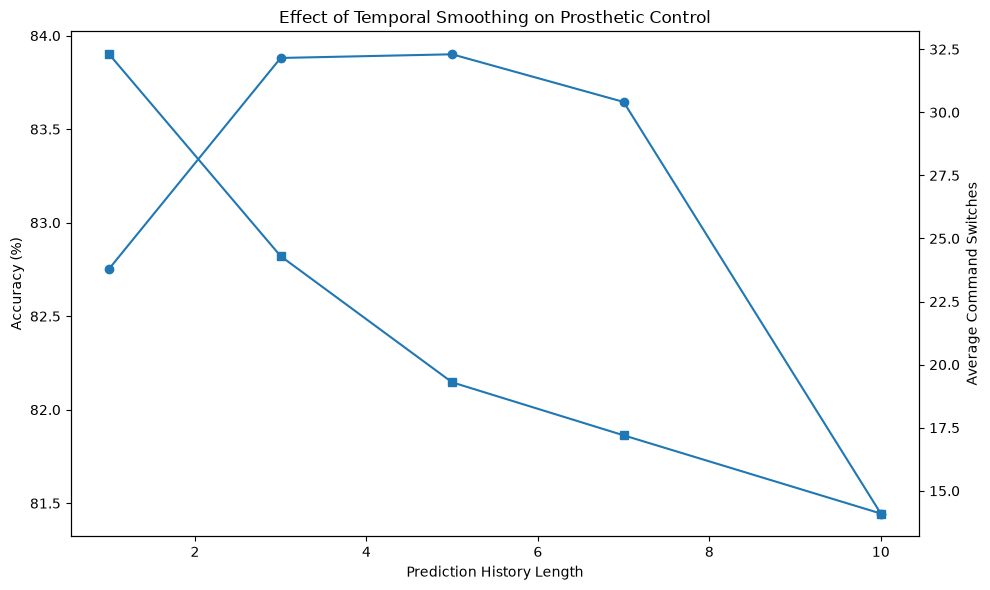

In [125]:
fig, ax1 = plt.subplots(figsize=(10, 6))

history = summary.index
accuracy = summary["mean_accuracy"] * 100
switches = summary["mean_switches"]

ax1.plot(
    history,
    accuracy,
    marker="o",
    label="Accuracy"
)

ax1.set_xlabel("Prediction History Length")
ax1.set_ylabel("Accuracy (%)")

ax2 = ax1.twinx()

ax2.plot(
    history,
    switches,
    marker="s",
    label="Command Switches"
)

ax2.set_ylabel("Average Command Switches")

plt.title(
    "Effect of Temporal Smoothing on Prosthetic Control"
)

fig.tight_layout()

plt.savefig(
    "../results/temporal_smoothing_experiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [126]:
summary.to_csv(
    "../results/temporal_smoothing_experiment.csv"
)

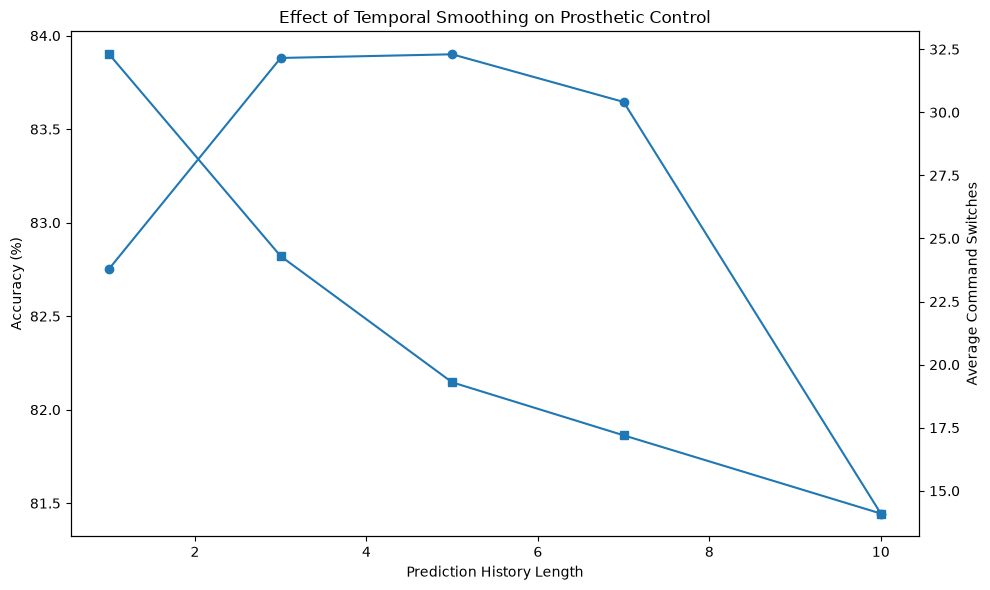

In [127]:
fig, ax1 = plt.subplots(figsize=(10, 6))

history = summary.index
accuracy = summary["mean_accuracy"] * 100
switches = summary["mean_switches"]

ax1.plot(
    history,
    accuracy,
    marker="o"
)

ax1.set_xlabel("Prediction History Length")
ax1.set_ylabel("Accuracy (%)")

ax2 = ax1.twinx()

ax2.plot(
    history,
    switches,
    marker="s"
)

ax2.set_ylabel("Average Command Switches")

plt.title(
    "Effect of Temporal Smoothing on Prosthetic Control"
)

fig.tight_layout()

plt.savefig(
    "../results/temporal_smoothing_experiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()